In [1]:
import sys
print(sys.version)

3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


In [3]:
pip install tensorflow==2.15.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\Users\user\Documents\my_python\tf311_env\Scripts\python.exe -m pip install --upgrade pip


In [4]:
import tensorflow as tf
print(tf.__version__)


2.15.0


In [7]:
import sys
!{sys.executable} -m pip install pandas

     ---------------------------------------- 9.9/9.9 MB 3.3 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\Users\user\Documents\my_python\tf311_env\Scripts\python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
print(pd.__version__)

3.0.3


In [10]:
import sys
!{sys.executable} -m pip install scikit-learn matplotlib seaborn nltk

     ---------------------------------------- 8.3/8.3 MB 3.9 MB/s eta 0:00:00
     ---------------------------------------- 9.3/9.3 MB 3.4 MB/s eta 0:00:00
     -------------------------------------- 294.9/294.9 kB 6.1 MB/s eta 0:00:00
     ---------------------------------------- 1.6/1.6 MB 3.9 MB/s eta 0:00:00
     ---------------------------------------- 36.6/36.6 MB 5.6 MB/s eta 0:00:00
     -------------------------------------- 309.1/309.1 kB 4.8 MB/s eta 0:00:00
     -------------------------------------- 454.8/454.8 kB 4.0 MB/s eta 0:00:00
     -------------------------------------- 225.2/225.2 kB 4.6 MB/s eta 0:00:00
     ---------------------------------------- 2.4/2.4 MB 6.0 MB/s eta 0:00:00
     ---------------------------------------- 73.5/73.5 kB 2.0 MB/s eta 0:00:00
     ---------------------------------------- 7.1/7.1 MB 4.9 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 7.0 MB/s eta 0:00:00
     -------------------------------------- 116.6/


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\Users\user\Documents\my_python\tf311_env\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense,GRU,LSTM,Dropout,Bidirectional
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [63]:
#load dataset
df=pd.read_csv('IMDB Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [64]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [5]:
df.shape

(50000, 2)

In [65]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [11]:
missing_values=df.isnull().sum()
missing_values[missing_values>0]

Series([], dtype: int64)

In [12]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


## EDA - visualization

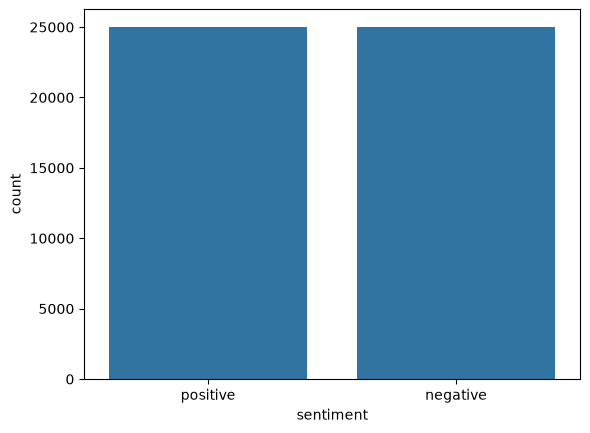

In [13]:
sns.countplot(x='sentiment', data=df)
plt.show()

In [66]:
from collections import Counter

all_words = " ".join(df['review']).split()
counter = Counter(all_words)
print(counter.most_common(20))

[('the', 568735), ('a', 306960), ('and', 301919), ('of', 283625), ('to', 261850), ('is', 203056), ('in', 169981), ('I', 132498), ('that', 126818), ('this', 113726), ('it', 107916), ('/><br', 100974), ('was', 92658), ('as', 83130), ('with', 82569), ('for', 80919), ('The', 67317), ('but', 66282), ('on', 61197), ('movie', 60762)]


**clean the sentance**

In [67]:
#clean the review.remove tags
from nltk.corpus import stopwords
from bs4 import BeautifulSoup
import re
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = BeautifulSoup(text,"html.parser").get_text()
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [69]:
df['clean_review'] = df['review'].apply(clean_text)

In [70]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


## Word2Vec

In [71]:
import sys
!{sys.executable} -m pip install gensim


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\Users\user\Documents\my_python\tf311_env\Scripts\python.exe -m pip install --upgrade pip


In [23]:
!pip install gensim
from gensim.models import Word2Vec

In [72]:
sentences = [review.split() for review in df['clean_review']]

w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)
w2v_model.wv['movie']

array([-9.2108762e-01, -2.5091067e-01, -1.4906319e+00,  3.4999171e-01,
        6.1174196e-01,  2.5435260e-01, -8.3053672e-01,  4.3362972e-01,
       -1.6632071e-01, -1.7139913e+00,  2.5181824e-01,  3.8195482e-01,
       -4.9784172e-01,  2.2588816e+00, -1.3231729e+00,  7.5396329e-01,
        9.2942286e-01,  5.7045805e-01,  2.9749105e-02, -9.2747730e-01,
        8.5569102e-01,  5.8564216e-01,  9.1338640e-01, -1.2769554e+00,
        1.3256719e+00,  2.2115289e-01,  7.5513279e-01,  9.2257738e-01,
        1.5726081e-01,  1.0665381e+00,  5.7364378e-02, -4.8963630e-01,
        3.2882090e+00, -2.6029778e+00, -1.6185360e+00,  3.0526953e+00,
        6.6354066e-01, -4.5889682e-01,  7.6133215e-01,  7.0479959e-02,
        7.0447737e-01,  2.8368378e-01,  5.9495986e-01,  1.0437452e+00,
       -1.6476295e+00,  6.8395818e-03, -7.8867239e-01, -2.7784567e+00,
       -5.7864243e-01,  1.4162509e-01, -2.0552988e+00, -2.0357323e-01,
        4.1209903e-01,  1.8670604e-01, -1.8418732e-01, -1.3695298e+00,
      

## label encoding

In [73]:
sentiment_lab = {
    'positive': 1,
    'negative': 0,
}

df['sentiment']=df['sentiment'].map(sentiment_lab)

In [74]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visually stunnin...


## test train split

In [75]:
x=df['clean_review']
y=df['sentiment']
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## Tokenization

(converts words into numbers because neural networks cannot understand text directly. )

In [170]:
# max_words = 20000
# tokenizer = Tokenizer(num_words=max_words)
# tokenizer.fit_on_texts(X_train)
# #text into seq
# X_train_seq = tokenizer.texts_to_sequences(X_train)
# X_test_seq = tokenizer.texts_to_sequences(X_test)
#X_train_seq
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [171]:
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    train_seq,
    maxlen=200
)

X_test_pad = pad_sequences(
    test_seq,
    maxlen=200
)

## Word Cloud

In [172]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

X = vectorizer.fit_transform(df['clean_review'])
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 28413 stored elements and shape (50000, 20)>

## TF-IDF

In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3444433 stored elements and shape (40000, 10000)>

In [80]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(
    X_train_tfidf,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [87]:
log_predictions=log_model.predict(X_test_tfidf)
print("\npredictions:")
print(log_predictions)


predictions:
[0 1 0 ... 1 0 1]


In [86]:
# accuracy = accuracy_score(y_test, log_predictions)

log_accuracy = accuracy_score(y_test, log_predictions)
print("Accuracy:", log_accuracy)

Accuracy: 0.8957


In [83]:
print("\nClassification Report:")
print(classification_report(y_test, log_predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      4961
           1       0.88      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [85]:
from sklearn.metrics import roc_auc_score

# Probability predictions
y_prob = log_model.predict_proba(X_test_tfidf)[:, 1]


roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9616341458214319


## Logistic regression-result

- Accuracy: 90%
- Precision: 88%
- Recall: 91%
- F1 Score: 90%
- ROC-AUC: 0.96%

## LSTM model

In [173]:
vocab_size = len(tokenizer.word_index) + 1
#print(vocab_size)
lstm_model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=200
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        )
    ),

    Dropout(0.5),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

In [174]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [175]:
history_lstm=lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
500/500 [==============================] - 1306s 3s/step - loss: 0.3618 - accuracy: 0.8331 - val_loss: 0.3015 - val_accuracy: 0.8701
Epoch 2/10
500/500 [==============================] - 263s 525ms/step - loss: 0.2150 - accuracy: 0.9185 - val_loss: 0.3212 - val_accuracy: 0.8590
Epoch 3/10
500/500 [==============================] - 281s 562ms/step - loss: 0.1580 - accuracy: 0.9407 - val_loss: 0.3230 - val_accuracy: 0.8729
Epoch 4/10
500/500 [==============================] - 325s 650ms/step - loss: 0.1116 - accuracy: 0.9585 - val_loss: 0.3941 - val_accuracy: 0.8729
Epoch 5/10
500/500 [==============================] - 271s 542ms/step - loss: 0.0847 - accuracy: 0.9707 - val_loss: 0.4423 - val_accuracy: 0.8505
Epoch 6/10
500/500 [==============================] - 271s 541ms/step - loss: 0.0699 - accuracy: 0.9759 - val_loss: 0.4754 - val_accuracy: 0.8481
Epoch 7/10
500/500 [==============================] - 591s 1s/step - loss: 0.0530 - accuracy: 0.9825 - val_loss: 0.5671 - val_

In [176]:
lstm_model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_8 (Embedding)     (None, 200, 128)          11826688  
                                                                 
 bidirectional_8 (Bidirecti  (None, 128)               98816     
 onal)                                                           
                                                                 
 dropout_8 (Dropout)         (None, 128)               0         
                                                                 
 dense_15 (Dense)            (None, 64)                8256      
                                                                 
 dense_16 (Dense)            (None, 1)                 65        
                                                                 
Total params: 11933825 (45.52 MB)
Trainable params: 11933825 (45.52 MB)
Non-trainable params: 0 (0.00 Byte)
____________

In [177]:
print(y_train.head())

39087    0
30893    0
45278    1
16398    0
13653    0
Name: sentiment, dtype: int64


## GRU

In [138]:
gru_model = Sequential([
    Embedding(vocab_size,128,input_length=200 ),
    Bidirectional( GRU(64)),
    Dropout(0.5),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [140]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [142]:
history_gru=gru_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64
)

Epoch 1/5
500/500 [==============================] - 186s 370ms/step - loss: 0.2873 - accuracy: 0.8835 - val_loss: 0.2970 - val_accuracy: 0.8817
Epoch 2/5
500/500 [==============================] - 244s 489ms/step - loss: 0.1618 - accuracy: 0.9404 - val_loss: 0.3315 - val_accuracy: 0.8665
Epoch 3/5
500/500 [==============================] - 221s 442ms/step - loss: 0.0983 - accuracy: 0.9656 - val_loss: 0.3742 - val_accuracy: 0.8774
Epoch 4/5
500/500 [==============================] - 222s 443ms/step - loss: 0.0610 - accuracy: 0.9801 - val_loss: 0.4482 - val_accuracy: 0.8714
Epoch 5/5
500/500 [==============================] - 222s 444ms/step - loss: 0.0427 - accuracy: 0.9854 - val_loss: 0.5329 - val_accuracy: 0.8091


In [143]:
gru_model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_6 (Embedding)     (None, 200, 128)          11826560  
                                                                 
 bidirectional_6 (Bidirecti  (None, 128)               74496     
 onal)                                                           
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_12 (Dense)            (None, 64)                8256      
                                                                 
 dense_13 (Dense)            (None, 1)                 65        
                                                                 
Total params: 11909377 (45.43 MB)
Trainable params: 11909377 (45.43 MB)
Non-trainable params: 0 (0.00 Byte)
____________

## LSTM-dropout(avoid overfitting)

here validation accuracy,loss deceases while reached in final epochs.so use ealry stopping method.

In [193]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1
)
# lstm_model = Sequential([
#     Embedding(vocab_size, 128, input_length=200),
#     Bidirectional(LSTM(64,return_sequences=False)),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])


In [194]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [195]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/10
500/500 [==============================] - 170s 330ms/step - loss: 0.0386 - accuracy: 0.9876 - val_loss: 0.6382 - val_accuracy: 0.8655 - lr: 0.0010
Epoch 2/10
500/500 [==============================] - 162s 324ms/step - loss: 0.0140 - accuracy: 0.9959 - val_loss: 0.8455 - val_accuracy: 0.8648 - lr: 0.0010
Epoch 3/10
500/500 [==============================] - 165s 329ms/step - loss: 0.0077 - accuracy: 0.9978 - val_loss: 0.8973 - val_accuracy: 0.8645 - lr: 5.0000e-04
Epoch 4/10
500/500 [==============================] - 166s 332ms/step - loss: 0.0023 - accuracy: 0.9995 - val_loss: 1.0205 - val_accuracy: 0.8624 - lr: 2.5000e-04


**predict**

In [196]:
y_pred_prob = lstm_model.predict(X_test_pad)

313/313 [==============================] - 23s 63ms/step


In [199]:
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

In [200]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8604

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      4961
           1       0.88      0.84      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [215]:
loss, acc = lstm_model.evaluate(X_test_pad, y_test)
print("Accuracy:", acc)

313/313 [==============================] - 25s 78ms/step - loss: 0.6588 - accuracy: 0.8604
Accuracy: 0.8604000210762024


In [208]:
#predict sentiment of a new review using lstm
max_len = 200
new_review=['bad movie']
new_seq=tokenizer.texts_to_sequences(new_review)
new_pad=pad_sequences(new_seq,padding='post',maxlen=max_len)

prediction=lstm_model.predict(new_pad)
sentiment="positive" if prediction[0][0] >=0.5 else "negative"
print(f"review statement:{sentiment}")

1/1 [==============================] - 0s 92ms/step
review statement:negative


## confution matrix-lstm

<Axes: >

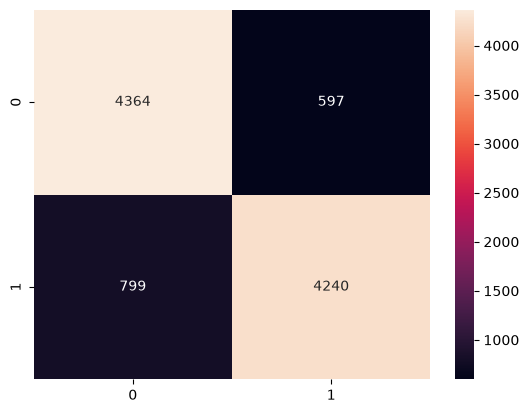

In [210]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

## Training Curves

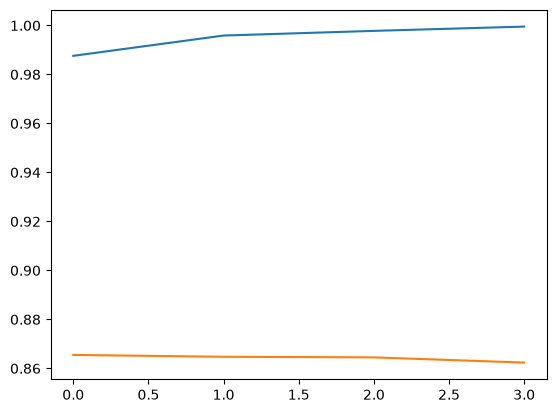

In [211]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

## Error Analysis

In [212]:
misclassified = df.loc[y_test.index][y_pred != y_test]

misclassified.head(10)

,review,sentiment,clean_review
33553,I really liked this Summerslam due to the look...,1,really liked summerslam due look arena curtain...
9427,Not many television shows appeal to quite as m...,1,many television shows appeal quite many differ...
49498,"Okay, I didn't get the Purgatory thing the fir...",1,okay get purgatory thing first time watched ep...
4144,I was very disappointed with this series. It h...,0,disappointed series lots cool graphics level d...
29282,This movie starts off somewhat slowly and gets...,1,movie starts somewhat slowly gets running towa...
15118,"This movie was released originally as a soft ""...",1,movie released originally soft x apparently ex...
37237,I'm writing this note as a chess player as wel...,0,writing note chess player well movie viewer wa...
33109,Three kids are born during a solar eclipse and...,1,three kids born solar eclipse turn vile murder...
22062,Though I can't claim to be a comic book fanati...,1,though claim comic book fanatic read share gue...
17523,Wasn't sure what to expect from this movie con...,1,sure expect movie considering amazing collecti...


## Model Saving

In [213]:
lstm_model.save((r"D:\my_flask7\sentiment_model.keras"))

In [214]:
import pickle

with open(
    r"D:\my_flask7\tokenizer.pkl",
    "wb"
) as f:
    pickle.dump(tokenizer,f)

## model comparison

| Model                        | Accuracy |
| ---------------------------- | -------- |
| Logistic Regression          | 89%      |
| LSTM                         | 86%      |
| GRU                          | 98%      |
